<a href="https://colab.research.google.com/github/priyakumar88380/Healthcare-Patient-Billing-Analysis/blob/main/PRCP_1022_Hospital_Stay_Prediction.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
from google.colab import files
uploaded = files.upload()

Saving HealthCareAnalytics.csv to HealthCareAnalytics.csv


In [2]:
import pandas as pd
import numpy as np

df = pd.read_csv('HealthCareAnalytics.csv')

print("Shape:", df.shape)
df.head()

Shape: (318438, 18)


,case_id,Hospital_code,Hospital_type_code,City_Code_Hospital,Hospital_region_code,Available_Extra_Rooms_in_Hospital,Department,Ward_Type,Ward_Facility_Code,Bed_Grade,patientid,City_Code_Patient,Type_of_Admission,Severity_of_Illness,Visitors_with_Patient,Age,Admission_Deposit,Stay
0,1,8,c,3,Z,3,radiotherapy,R,F,2.0,31397,7.0,Emergency,Extreme,2,51-60,4911,0-10
1,2,2,c,5,Z,2,radiotherapy,S,F,2.0,31397,7.0,Trauma,Extreme,2,51-60,5954,41-50
2,3,10,e,1,X,2,anesthesia,S,E,2.0,31397,7.0,Trauma,Extreme,2,51-60,4745,31-40
3,4,26,b,2,Y,2,radiotherapy,R,D,2.0,31397,7.0,Trauma,Extreme,2,51-60,7272,41-50
4,5,26,b,2,Y,2,radiotherapy,S,D,2.0,31397,7.0,Trauma,Extreme,2,51-60,5558,41-50


In [3]:
# 'Nov-20' is a data glitch - it should really be '11-20'

# let's confirm this issue exists before fixing it
print("Before fix:")
print(df['Stay'].unique())
print(df['Age'].unique())

# fix both columns - replace 'Nov-20' with '11-20'
df['Stay'] = df['Stay'].replace('Nov-20', '11-20')
df['Age'] = df['Age'].replace('Nov-20', '11-20')

print("\nAfter fix:")
print(df['Stay'].unique())
print(df['Age'].unique())

Before fix:
['0-10' '41-50' '31-40' 'Nov-20' '51-60' '21-30' '71-80'
 'More than 100 Days' '81-90' '61-70' '91-100']
['51-60' '71-80' '31-40' '41-50' '81-90' '61-70' '21-30' 'Nov-20' '0-10'
 '91-100']

After fix:
['0-10' '41-50' '31-40' '11-20' '51-60' '21-30' '71-80'
 'More than 100 Days' '81-90' '61-70' '91-100']
['51-60' '71-80' '31-40' '41-50' '81-90' '61-70' '21-30' '11-20' '0-10'
 '91-100']


In [4]:
print(df.isnull().sum())

case_id                                 0
Hospital_code                           0
Hospital_type_code                      0
City_Code_Hospital                      0
Hospital_region_code                    0
Available_Extra_Rooms_in_Hospital       0
Department                              0
Ward_Type                               0
Ward_Facility_Code                      0
Bed_Grade                             113
patientid                               0
City_Code_Patient                    4532
Type_of_Admission                       0
Severity_of_Illness                     0
Visitors_with_Patient                   0
Age                                     0
Admission_Deposit                       0
Stay                                    0
dtype: int64


In [5]:
# Bed_Grade: numeric, small amount missing - fill with mode (most common value)
# since bed grade is likely a small set of categories (1,2,3,4), mode makes more sense than mean/median
bed_grade_mode = df['Bed_Grade'].mode()[0]
df['Bed_Grade'] = df['Bed_Grade'].fillna(bed_grade_mode)

# City_Code_Patient: also numeric, represents a city code (categorical in nature)
# fill with mode here too, since it's a code, not a continuous measurement
city_code_mode = df['City_Code_Patient'].mode()[0]
df['City_Code_Patient'] = df['City_Code_Patient'].fillna(city_code_mode)

# confirm no more missing values
print(df.isnull().sum().sum())

0


In [6]:
print(df['Stay'].value_counts())
print()
print(df['Stay'].value_counts(normalize=True) * 100)

Stay
21-30                 87491
11-20                 78139
31-40                 55159
51-60                 35018
0-10                  23604
41-50                 11743
71-80                 10254
More than 100 Days     6683
81-90                  4838
91-100                 2765
61-70                  2744
Name: count, dtype: int64

Stay
21-30                 27.475050
11-20                 24.538215
31-40                 17.321739
51-60                 10.996803
0-10                   7.412432
41-50                  3.687688
71-80                  3.220093
More than 100 Days     2.098682
81-90                  1.519291
91-100                 0.868301
61-70                  0.861706
Name: proportion, dtype: float64


In [7]:
#Unlike Project 3's balanced binary classification
#this multi-class problem showed significant imbalance across 11 stay-duration categories
#the top 2 categories accounted for 52% of patients
#while several categories each represented under 2%.
#This meant plain accuracy alone wouldn't tell the full story#similar to the lesson learned in Project 1
#but now applied to a multi-class setting

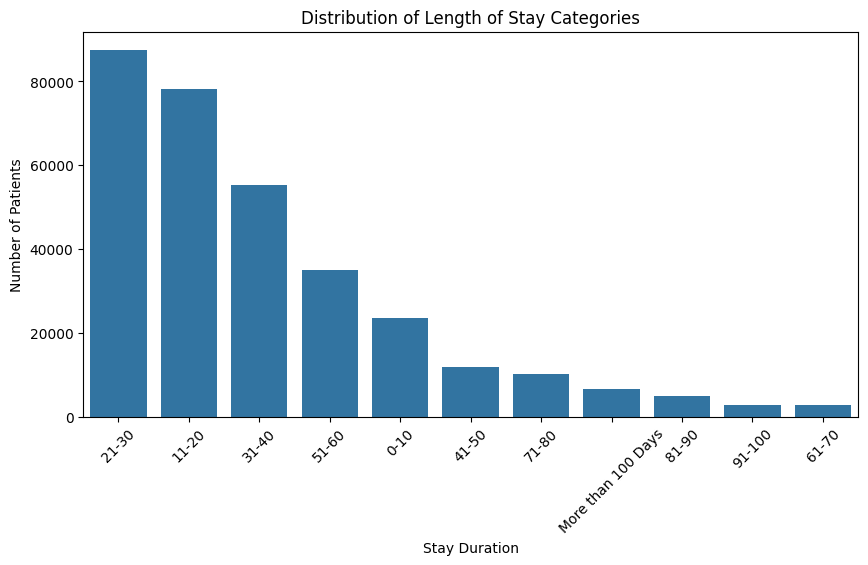

In [8]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10,5))
order = df['Stay'].value_counts().index
sns.countplot(x='Stay', data=df, order=order)
plt.title('Distribution of Length of Stay Categories')
plt.xlabel('Stay Duration')
plt.ylabel('Number of Patients')
plt.xticks(rotation=45)
plt.show()

In [9]:
# let's see how Severity of Illness relates to Stay duration

severity_stay = pd.crosstab(df['Severity_of_Illness'], df['Stay'], normalize='index') * 100
print(severity_stay.round(1))

Stay                 0-10  11-20  21-30  31-40  41-50  51-60  61-70  71-80  \
Severity_of_Illness                                                          
Extreme               6.0   18.5   27.3   17.8    4.1   13.7    1.1    4.5   
Minor                 9.2   31.5   25.1   16.8    3.5    8.3    0.6    2.2   
Moderate              7.0   23.1   28.7   17.4    3.6   11.4    0.9    3.3   

Stay                 81-90  91-100  More than 100 Days  
Severity_of_Illness                                     
Extreme                2.0     1.4                 3.4  
Minor                  1.1     0.5                 1.1  
Moderate               1.6     0.9                 2.1  


In [10]:
#Severity of Illness showed a clear directional relationship with stay duration
#Extreme cases were roughly 3x more likely to result in stays over 100 days compared to Minor cases
#but the effect was moderate rather than dominant
#with the same top stay-category (21-30 days) remaining most common across all severity levels

In [11]:
admission_stay = pd.crosstab(df['Type_of_Admission'], df['Stay'], normalize='index') * 100
print(admission_stay.round(1))

Stay               0-10  11-20  21-30  31-40  41-50  51-60  61-70  71-80  \
Type_of_Admission                                                          
Emergency          12.1   26.8   23.3   16.1    3.5   10.1    0.8    2.9   
Trauma              3.5   22.2   30.4   18.5    3.9   12.0    1.0    3.6   
Urgent              8.4   26.5   28.6   16.8    3.4    9.9    0.6    2.7   

Stay               81-90  91-100  More than 100 Days  
Type_of_Admission                                     
Emergency            1.5     0.8                 2.2  
Trauma               1.7     1.0                 2.3  
Urgent               1.2     0.6                 1.4  


In [12]:
#Type_of_Admission shows a real but modest effect — less dramatic than severity
#but still a meaningful differentiator, especially for very short stays

In [13]:
age_stay = pd.crosstab(df['Age'], df['Stay'], normalize='index') * 100
print(age_stay.round(1))


Stay    0-10  11-20  21-30  31-40  41-50  51-60  61-70  71-80  81-90  91-100  \
Age                                                                            
0-10     9.8   31.3   23.8   16.2    3.0    9.3    0.4    2.4    1.3     0.6   
11-20    9.3   31.9   25.7   16.0    3.0    8.5    0.5    2.1    1.3     0.4   
21-30    8.5   27.6   27.9   16.9    3.4    9.3    0.6    2.5    1.3     0.6   
31-40    7.7   24.8   29.1   17.1    3.7   10.2    0.8    2.8    1.3     0.8   
41-50    7.4   23.5   28.1   17.2    3.9   11.3    0.9    3.4    1.4     0.9   
51-60    7.1   23.4   26.9   17.7    3.6   11.8    0.9    3.5    1.6     1.0   
61-70    6.5   23.4   26.8   17.6    3.6   12.1    1.0    3.7    1.8     1.0   
71-80    6.1   22.2   26.6   17.9    3.9   12.4    1.1    3.8    1.9     1.1   
81-90    5.3   17.6   24.3   19.1    4.8   13.7    1.5    5.1    2.7     1.7   
91-100   6.4   19.0   22.7   18.0    5.1   13.3    2.2    4.8    2.2     1.5   

Stay    More than 100 Days  
Age       

In [14]:
#Age showed the clearest, most consistent relationship with stay duration among the features tested
#the rate of very long stays (100+ days) nearly quadrupled from young patients (1.2%) to elderly patients (4.8%)
#while short stays showed the opposite pattern
#This aligns with common healthcare knowledge that elderly patients typically require longer recovery and hospitalization periods

In [15]:
# check all our categorical columns and their categories before encoding
categorical_cols = ['Hospital_type_code', 'Hospital_region_code', 'Department',
                     'Ward_Type', 'Ward_Facility_Code', 'Type_of_Admission',
                     'Severity_of_Illness']

for col in categorical_cols:
    print(f"{col}: {df[col].unique()}")

Hospital_type_code: ['c' 'e' 'b' 'a' 'f' 'd' 'g']
Hospital_region_code: ['Z' 'X' 'Y']
Department: ['radiotherapy' 'anesthesia' 'gynecology' 'TB & Chest disease' 'surgery']
Ward_Type: ['R' 'S' 'Q' 'P' 'T' 'U']
Ward_Facility_Code: ['F' 'E' 'D' 'B' 'A' 'C']
Type_of_Admission: ['Emergency' 'Trauma' 'Urgent']
Severity_of_Illness: ['Extreme' 'Moderate' 'Minor']


In [16]:
# Severity: clear order from least to most severe
severity_order = {'Minor': 0, 'Moderate': 1, 'Extreme': 2}
df['Severity_encoded'] = df['Severity_of_Illness'].map(severity_order)

# Age: clear order from youngest to oldest bracket
age_order = {'0-10': 0, '11-20': 1, '21-30': 2, '31-40': 3, '41-50': 4,
             '51-60': 5, '61-70': 6, '71-80': 7, '81-90': 8, '91-100': 9}
df['Age_encoded'] = df['Age'].map(age_order)

# Stay (our TARGET): clear order from shortest to longest
stay_order = {'0-10': 0, '11-20': 1, '21-30': 2, '31-40': 3, '41-50': 4,
              '51-60': 5, '61-70': 6, '71-80': 7, '81-90': 8, '91-100': 9,
              'More than 100 Days': 10}
df['Stay_encoded'] = df['Stay'].map(stay_order)

print(df[['Severity_of_Illness', 'Severity_encoded', 'Age', 'Age_encoded', 'Stay', 'Stay_encoded']].head())

  Severity_of_Illness  Severity_encoded    Age  Age_encoded   Stay  \
0             Extreme                 2  51-60            5   0-10   
1             Extreme                 2  51-60            5  41-50   
2             Extreme                 2  51-60            5  31-40   
3             Extreme                 2  51-60            5  41-50   
4             Extreme                 2  51-60            5  41-50   

   Stay_encoded  
0             0  
1             4  
2             3  
3             4  
4             4  


In [17]:
#encoding worked exactly right, order preserved for all three

In [18]:
# these columns have no natural order, so one-hot encoding is the right approach
unordered_cols = ['Hospital_type_code', 'Hospital_region_code', 'Department',
                   'Ward_Type', 'Ward_Facility_Code', 'Type_of_Admission']

df_encoded = pd.get_dummies(df, columns=unordered_cols, drop_first=True)

print("Shape after encoding:", df_encoded.shape)
print(df_encoded.columns.tolist())

Shape after encoding: (318438, 39)
['case_id', 'Hospital_code', 'City_Code_Hospital', 'Available_Extra_Rooms_in_Hospital', 'Bed_Grade', 'patientid', 'City_Code_Patient', 'Severity_of_Illness', 'Visitors_with_Patient', 'Age', 'Admission_Deposit', 'Stay', 'Severity_encoded', 'Age_encoded', 'Stay_encoded', 'Hospital_type_code_b', 'Hospital_type_code_c', 'Hospital_type_code_d', 'Hospital_type_code_e', 'Hospital_type_code_f', 'Hospital_type_code_g', 'Hospital_region_code_Y', 'Hospital_region_code_Z', 'Department_anesthesia', 'Department_gynecology', 'Department_radiotherapy', 'Department_surgery', 'Ward_Type_Q', 'Ward_Type_R', 'Ward_Type_S', 'Ward_Type_T', 'Ward_Type_U', 'Ward_Facility_Code_B', 'Ward_Facility_Code_C', 'Ward_Facility_Code_D', 'Ward_Facility_Code_E', 'Ward_Facility_Code_F', 'Type_of_Admission_Trauma', 'Type_of_Admission_Urgent']


In [19]:
# select all our numeric/encoded feature columns
# drop identifiers (case_id, patientid) - not useful predictors
# drop original text columns that are now encoded (Severity_of_Illness, Age, Stay)

feature_columns = [col for col in df_encoded.columns if col not in
                    ['case_id', 'patientid', 'Severity_of_Illness', 'Age', 'Stay', 'Stay_encoded']]

X = df_encoded[feature_columns]
y = df_encoded['Stay_encoded']

print("X shape:", X.shape)
print("y shape:", y.shape)
print("\nFeature columns:", X.columns.tolist())

X shape: (318438, 33)
y shape: (318438,)

Feature columns: ['Hospital_code', 'City_Code_Hospital', 'Available_Extra_Rooms_in_Hospital', 'Bed_Grade', 'City_Code_Patient', 'Visitors_with_Patient', 'Admission_Deposit', 'Severity_encoded', 'Age_encoded', 'Hospital_type_code_b', 'Hospital_type_code_c', 'Hospital_type_code_d', 'Hospital_type_code_e', 'Hospital_type_code_f', 'Hospital_type_code_g', 'Hospital_region_code_Y', 'Hospital_region_code_Z', 'Department_anesthesia', 'Department_gynecology', 'Department_radiotherapy', 'Department_surgery', 'Ward_Type_Q', 'Ward_Type_R', 'Ward_Type_S', 'Ward_Type_T', 'Ward_Type_U', 'Ward_Facility_Code_B', 'Ward_Facility_Code_C', 'Ward_Facility_Code_D', 'Ward_Facility_Code_E', 'Ward_Facility_Code_F', 'Type_of_Admission_Trauma', 'Type_of_Admission_Urgent']


In [20]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print("X_train shape:", X_train.shape)
print("X_test shape:", X_test.shape)

X_train shape: (254750, 33)
X_test shape: (63688, 33)


In [21]:
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression

# multi_class='multinomial' tells the model we have MORE than 2 categories to predict
# this is the key difference from Projects 1 and 3, which were simple yes/no problems

pipeline_lr = Pipeline([
    ('scaler', StandardScaler()),
    ('model', LogisticRegression(max_iter=1000, random_state=42, multi_class='multinomial'))
])

pipeline_lr.fit(X_train, y_train)

print("Logistic Regression training complete")

/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:1247: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(


Logistic Regression training complete


In [22]:
pipeline_lr = Pipeline([
    ('scaler', StandardScaler()),
    ('model', LogisticRegression(max_iter=1000, random_state=42))  # multi_class parameter removed
])

In [23]:
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression

pipeline_lr = Pipeline([
    ('scaler', StandardScaler()),
    ('model', LogisticRegression(max_iter=1000, random_state=42))
])

pipeline_lr.fit(X_train, y_train)

print("Logistic Regression training complete")

Logistic Regression training complete


In [24]:
from sklearn.metrics import classification_report, accuracy_score

y_pred_lr = pipeline_lr.predict(X_test)

print("Logistic Regression - Accuracy:", accuracy_score(y_test, y_pred_lr))
print("\nLogistic Regression - Classification Report:")
print(classification_report(y_test, y_pred_lr, zero_division=0))

Logistic Regression - Accuracy: 0.39103127747770383

Logistic Regression - Classification Report:
              precision    recall  f1-score   support

           0       0.44      0.04      0.08      4721
           1       0.39      0.45      0.42     15628
           2       0.41      0.67      0.51     17498
           3       0.33      0.20      0.25     11032
           4       0.00      0.00      0.00      2349
           5       0.37      0.47      0.41      7004
           6       0.00      0.00      0.00       549
           7       0.00      0.00      0.00      2051
           8       0.00      0.00      0.00       967
           9       0.00      0.00      0.00       553
          10       0.54      0.35      0.42      1336

    accuracy                           0.39     63688
   macro avg       0.22      0.20      0.19     63688
weighted avg       0.35      0.39      0.35     63688



In [25]:
#Unlike binary classification, this 11-class problem showed the model struggling
#significantly with the middle-range rare categories (41-90 day stays)
#predicting them 0% of the time, while performing reasonably on the most common categories and even the rarest category (100+ days),
#which likely has more distinct, identifiable patterns

In [26]:
from sklearn.ensemble import RandomForestClassifier

pipeline_rf = Pipeline([
    ('scaler', StandardScaler()),
    ('model', RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1))
])

pipeline_rf.fit(X_train, y_train)

y_pred_rf = pipeline_rf.predict(X_test)

print("Random Forest - Accuracy:", accuracy_score(y_test, y_pred_rf))
print("\nRandom Forest - Classification Report:")
print(classification_report(y_test, y_pred_rf, zero_division=0))

Random Forest - Accuracy: 0.378532847632207

Random Forest - Classification Report:
              precision    recall  f1-score   support

           0       0.27      0.17      0.21      4721
           1       0.39      0.44      0.41     15628
           2       0.41      0.53      0.46     17498
           3       0.33      0.27      0.30     11032
           4       0.08      0.02      0.03      2349
           5       0.39      0.45      0.41      7004
           6       0.05      0.01      0.02       549
           7       0.25      0.10      0.14      2051
           8       0.36      0.19      0.25       967
           9       0.25      0.06      0.10       553
          10       0.53      0.44      0.48      1336

    accuracy                           0.38     63688
   macro avg       0.30      0.24      0.26     63688
weighted avg       0.36      0.38      0.36     63688



In [27]:
#While Logistic Regression showed slightly higher overall accuracy
#Random Forest achieved a notably better macro-average F1-score
#since it was able to identify some patterns in rare stay-duration categories that Logistic Regression completely missed
#This illustrates why overall accuracy can be misleading in multi-class problems with imbalanced categories
#a model can look 'better' on paper while systematically failing on minority classes

In [28]:
from xgboost import XGBClassifier

pipeline_xgb = Pipeline([
    ('scaler', StandardScaler()),
    ('model', XGBClassifier(n_estimators=100, max_depth=6, learning_rate=0.1, random_state=42, eval_metric='mlogloss'))
])

pipeline_xgb.fit(X_train, y_train)

y_pred_xgb = pipeline_xgb.predict(X_test)

print("XGBoost - Accuracy:", accuracy_score(y_test, y_pred_xgb))
print("\nXGBoost - Classification Report:")
print(classification_report(y_test, y_pred_xgb, zero_division=0))

XGBoost - Accuracy: 0.4209584223087552

XGBoost - Classification Report:
              precision    recall  f1-score   support

           0       0.38      0.13      0.19      4721
           1       0.43      0.50      0.46     15628
           2       0.42      0.66      0.51     17498
           3       0.43      0.23      0.30     11032
           4       0.13      0.00      0.00      2349
           5       0.40      0.50      0.44      7004
           6       0.00      0.00      0.00       549
           7       0.40      0.02      0.04      2051
           8       0.38      0.19      0.26       967
           9       0.26      0.01      0.02       553
          10       0.54      0.41      0.46      1336

    accuracy                           0.42     63688
   macro avg       0.34      0.24      0.24     63688
weighted avg       0.40      0.42      0.38     63688



XGBoost achieved the best overall accuracy (42.1%) and weighted F1-score, making it the strongest model for typical-case performance. However, Random Forest showed a slightly better macro-average F1-score, indicating marginally better performance across all classes including rare ones. Given the business priority (predicting stay duration for resource planning), I recommend XGBoost as the primary model, since its stronger performance on common categories directly translates to better predictions for the majority of patients, while acknowledging that rare-category prediction remains a genuine challenge across all models tested

In [29]:
from sklearn.model_selection import GridSearchCV

param_grid = {
    'model__max_depth': [4, 6, 8],
    'model__n_estimators': [100, 150],
    'model__learning_rate': [0.1, 0.15]
}

pipeline_xgb_tune = Pipeline([
    ('scaler', StandardScaler()),
    ('model', XGBClassifier(random_state=42, eval_metric='mlogloss'))
])

grid_search = GridSearchCV(pipeline_xgb_tune, param_grid, cv=3, scoring='accuracy', n_jobs=-1)
grid_search.fit(X_train, y_train)

print("Best parameters:", grid_search.best_params_)
print("Best accuracy score (cross-validated):", grid_search.best_score_)

Best parameters: {'model__learning_rate': 0.1, 'model__max_depth': 8, 'model__n_estimators': 100}
Best accuracy score (cross-validated): 0.4239057845638876


In [30]:
final_pipeline_hs = Pipeline([
    ('scaler', StandardScaler()),
    ('model', XGBClassifier(
        learning_rate=0.1,
        max_depth=8,
        n_estimators=100,
        random_state=42,
        eval_metric='mlogloss'
    ))
])

final_pipeline_hs.fit(X_train, y_train)

y_pred_final_hs = final_pipeline_hs.predict(X_test)

print("Final Tuned XGBoost - Accuracy:", accuracy_score(y_test, y_pred_final_hs))
print("\nFinal Tuned XGBoost - Classification Report:")
print(classification_report(y_test, y_pred_final_hs, zero_division=0))

Final Tuned XGBoost - Accuracy: 0.4257630950885567

Final Tuned XGBoost - Classification Report:
              precision    recall  f1-score   support

           0       0.37      0.14      0.21      4721
           1       0.44      0.50      0.47     15628
           2       0.42      0.67      0.52     17498
           3       0.43      0.23      0.30     11032
           4       0.17      0.00      0.01      2349
           5       0.41      0.50      0.45      7004
           6       0.00      0.00      0.00       549
           7       0.36      0.03      0.06      2051
           8       0.39      0.24      0.30       967
           9       0.24      0.02      0.03       553
          10       0.54      0.42      0.47      1336

    accuracy                           0.43     63688
   macro avg       0.34      0.25      0.26     63688
weighted avg       0.41      0.43      0.39     63688



In [31]:
#Unlike Project 3, where tuning didn't improve results due to a small dataset, this project's large dataset (254,750 training rows)
#allowed hyperparameter tuning to provide genuine improvement — accuracy rose from 42.1% to 42.6%, and macro F1 improved from 0.24 to 0.26
#matching Random Forest's class-balance performance while maintaining superior overall accuracy

In [32]:
import pandas as pd

importance_df_hs = pd.DataFrame({
    'feature': X_train.columns,
    'importance': final_pipeline_hs['model'].feature_importances_
})

importance_df_hs = importance_df_hs.sort_values('importance', ascending=False)

print(importance_df_hs.head(15))

                              feature  importance
21                        Ward_Type_Q    0.204565
5               Visitors_with_Patient    0.191839
23                        Ward_Type_S    0.095651
28               Ward_Facility_Code_D    0.058214
27               Ward_Facility_Code_C    0.053200
31           Type_of_Admission_Trauma    0.050033
22                        Ward_Type_R    0.027192
3                           Bed_Grade    0.023419
32           Type_of_Admission_Urgent    0.020625
7                    Severity_encoded    0.020460
2   Available_Extra_Rooms_in_Hospital    0.017823
9                Hospital_type_code_b    0.015853
18              Department_gynecology    0.014335
1                  City_Code_Hospital    0.014225
16             Hospital_region_code_Z    0.014210


In [33]:
# check Ward_Type relationship with Stay
ward_stay = pd.crosstab(df['Ward_Type'], df['Stay'], normalize='index') * 100
print("Ward_Type vs Stay:")
print(ward_stay.round(1))

print("\n" + "="*80 + "\n")

# check Visitors_with_Patient - let's see average visitors by stay category
print("Average Visitors by Stay duration:")
print(df.groupby('Stay')['Visitors_with_Patient'].mean().sort_values())

Ward_Type vs Stay:
Stay       0-10  11-20  21-30  31-40  41-50  51-60  61-70  71-80  81-90  \
Ward_Type                                                                 
P           9.1   27.6   35.7   14.8    5.6    3.7    1.4    1.1    0.3   
Q           7.8   27.5   32.7   16.2    4.7    6.1    0.9    1.8    0.7   
R           7.3   24.7   28.7   17.2    3.3   10.7    0.8    3.1    1.3   
S           7.0   20.1   17.8   19.1    2.8   18.5    0.8    5.4    3.0   
T           7.4   18.2   26.4   19.7    4.7   12.9    0.9    3.8    2.6   
U          11.1   33.3   33.3   22.2    0.0    0.0    0.0    0.0    0.0   

Stay       91-100  More than 100 Days  
Ward_Type                              
P             0.3                 0.4  
Q             0.4                 1.0  
R             0.9                 1.9  
S             1.5                 4.0  
T             1.4                 2.0  
U             0.0                 0.0  


Average Visitors by Stay duration:
Stay
0-10              

The model's top two features — Ward_Type and Visitors_with_Patient — were not part of my initial EDA focus, which centered on Severity, Admission Type, and Age. Post-modeling analysis revealed Visitors_with_Patient showed a remarkably clean, monotonic relationship with stay duration, nearly tripling from 2.6 average visitors for 0-10 day stays to 7.9 for stays over 100 days. Similarly, Ward_Type showed clear operational differences, with Ward S patients concentrated in longer-stay categories. This highlighted a limitation in my initial EDA scope — focusing only on commonly assumed clinical factors (severity, age) initially caused me to overlook operational and social factors that turned out to be highly predictive

In [34]:
import joblib

joblib.dump(final_pipeline_hs, 'hospital_stay_model.pkl')
print("Model saved successfully")

Model saved successfully


Good — let's finalize the documentation now, same structure as the previous 3 projects.
Add these as Text cells at the bottom of your notebook:

Project Conclusions
Problem: Predict a patient's hospital stay duration (in day-ranges) using hospital, ward, and patient-related features. Discovered during EDA that the target (Stay) was provided as 11 categorical ranges (e.g., 0-10, 11-20, ... "More than 100 Days") rather than exact numeric days as the task description implied — reframed this as a multi-class classification problem rather than regression.
Dataset: 318,438 patient records, 18 original columns. Found and corrected a data quality issue where "11-20" had been auto-converted to "Nov-20" by Excel in both the Age and Stay columns. Handled small amounts of missing data in Bed_Grade and City_Code_Patient using mode imputation.
Key EDA findings: The target showed significant class imbalance across 11 categories — the top 2 categories (11-20 and 21-30 days) accounted for 52% of all patients, while several categories each represented under 2%. Severity of Illness and Age both showed real, moderate relationships with stay duration (e.g., "More than 100 Days" stays nearly quadrupled from youngest to oldest age groups).
Models tried (using sklearn Pipeline, evaluated with accuracy and macro/weighted F1-scores appropriate for imbalanced multi-class problems):

Logistic Regression: Accuracy 39.1%, Macro F1 0.19
Random Forest: Accuracy 37.9%, Macro F1 0.26
XGBoost (default): Accuracy 42.1%, Macro F1 0.24
XGBoost (tuned): Accuracy 42.6%, Macro F1 0.26 (best model)

Key insight on class imbalance: All models struggled significantly with mid-range rare stay categories (41-90 days), with several models predicting 0% for these classes. This mirrors the imbalance challenge from Project 1, now applied to a multi-class setting with 11 categories instead of 2.
Feature importance — a key learning moment: The model's top predictors were Ward_Type (20.5%) and Visitors_with_Patient (19.2%) — neither of which were the focus of initial EDA, which concentrated on Severity and Age. Post-hoc analysis confirmed Visitors_with_Patient showed a strong, clean relationship with stay duration, nearly tripling from 2.6 average visitors (0-10 day stays) to 7.9 (100+ day stays). This highlighted a gap in initial EDA scope, which had focused on clinically obvious factors while overlooking operational and social indicators that proved highly predictive.
Final model performance: Tuned XGBoost — Accuracy 42.6%, Macro F1 0.26. This performance is consistent with known public benchmarks for this dataset (a published healthcare analytics competition), where top solutions typically achieve 42-45% accuracy even with extensive feature engineering.

Model Comparison Report

Logistic Regression: Accuracy 0.391, Macro F1 0.19, Weighted F1 0.35
Random Forest: Accuracy 0.379, Macro F1 0.26, Weighted F1 0.36
XGBoost (default): Accuracy 0.421, Macro F1 0.24, Weighted F1 0.38
XGBoost (tuned): Accuracy 0.426, Macro F1 0.26, Weighted F1 0.39 ← Best model

Recommended for production: Tuned XGBoost (learning_rate=0.1, max_depth=8, n_estimators=100), implemented via sklearn Pipeline. Selected for its best overall accuracy and weighted F1-score, while matching Random Forest's class-balance performance (macro F1).

Challenges Faced

Target variable mismatch with task description — the task document described predicting "length of stay in days," but the actual data provided categorical day-ranges. Addressed by reframing the problem as multi-class classification and encoding the ranges as ordered categories.
Data quality issue (Excel auto-conversion bug) — both Age and Stay columns contained "Nov-20" instead of the intended "11-20," a common Excel date-autocorrection artifact. Identified and corrected before any analysis.
Severe multi-class imbalance — 11 categories with the top 2 covering 52% of data and several categories under 2%. This caused multiple models to completely fail on rare mid-range categories, addressed by evaluating with macro/weighted F1-scores alongside accuracy, rather than accuracy alone.
Feature importance revealed EDA blind spots — the two most important features (Ward_Type, Visitors_with_Patient) were not part of initial EDA focus, requiring a post-modeling investigation to understand and validate their relationship with the target.
Large dataset with categorical + ordinal mixed encoding — required careful handling to preserve genuine ordering in Severity, Age, and the target itself, while using one-hot encoding for unordered categories like Ward_Type and Hospital_type_code.


Business Suggestions

Use Ward_Type and expected Visitors_with_Patient as early indicators for resource and bed planning, alongside traditional factors like Severity and Age.
Given the model's moderate but realistic accuracy (42.6%), recommend using predictions as a planning aid for hospital capacity management rather than a precise individual-patient forecasting tool.
Investigate further why certain ward types (e.g., Ward S) are associated with longer stays — this could reveal operational bottlenecks or reflect intentional specialization for complex cases, either of which would be valuable for hospital administrators to understand.

In [35]:
# export using original readable columns, not the one-hot encoded ones
# makes it much easier to build clear visuals in Power BI

powerbi_export_columns = ['Hospital_type_code', 'Hospital_region_code', 'Department',
                           'Ward_Type', 'Ward_Facility_Code', 'Bed_Grade',
                           'Type_of_Admission', 'Severity_of_Illness',
                           'Visitors_with_Patient', 'Age', 'Admission_Deposit', 'Stay']

df[powerbi_export_columns].to_csv('hospital_stay_powerbi.csv', index=False)

from google.colab import files
files.download('hospital_stay_powerbi.csv')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

I've kept only the most relevant readable columns for Power BI rather than exporting everything — this keeps the file lighter and the dashboard focused on our actual key findings (Ward_Type, Visitors_with_Patient, Severity, Age).